📊 German Credit Risk — Data Cleaning &

Preparation

MLOps Project — Phase 1

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


2. Load the Dataset

In [2]:
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'EmploymentDuration', 'InstallmentRate', 'PersonalStatusSex',
    'OtherDebtors', 'ResidenceDuration', 'Property', 'Age',
    'OtherInstallmentPlans', 'Housing', 'ExistingCredits',
    'Job', 'PeopleLiable', 'Telephone', 'ForeignWorker', 'Target'
]

df = pd.read_csv('german.data', sep=' ', header=None, names=columns)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1000, 21)


,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentDuration,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,PeopleLiable,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


3. Initial Inspection

In [3]:
print('=== Column Info ===')
df.info()

print('\n=== Statistical Summary ===')
df.describe()

print('\n=== Unique Values ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Status                 1000 non-null   object
 1   Duration               1000 non-null   int64 
 2   CreditHistory          1000 non-null   object
 3   Purpose                1000 non-null   object
 4   CreditAmount           1000 non-null   int64 
 5   Savings                1000 non-null   object
 6   EmploymentDuration     1000 non-null   object
 7   InstallmentRate        1000 non-null   int64 
 8   PersonalStatusSex      1000 non-null   object
 9   OtherDebtors           1000 non-null   object
 10  ResidenceDuration      1000 non-null   int64 
 11  Property               1000 non-null   object
 12  Age                    1000 non-null   int64 
 13  OtherInstallmentPlans  1000 non-null   object
 14  Housing                1000 non-null   object
 15  Ex

4. Fix Target Variable

In [4]:
df['Target'] = df['Target'].map({1: 0, 2: 1})

print(df['Target'].value_counts())

Target
0    700
1    300
Name: count, dtype: int64


5. Handle Missing Values

In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
Status                   0
Duration                 0
CreditHistory            0
Purpose                  0
CreditAmount             0
Savings                  0
EmploymentDuration       0
InstallmentRate          0
PersonalStatusSex        0
OtherDebtors             0
ResidenceDuration        0
Property                 0
Age                      0
OtherInstallmentPlans    0
Housing                  0
ExistingCredits          0
Job                      0
PeopleLiable             0
Telephone                0
ForeignWorker            0
Target                   0
dtype: int64


6. Explore Target

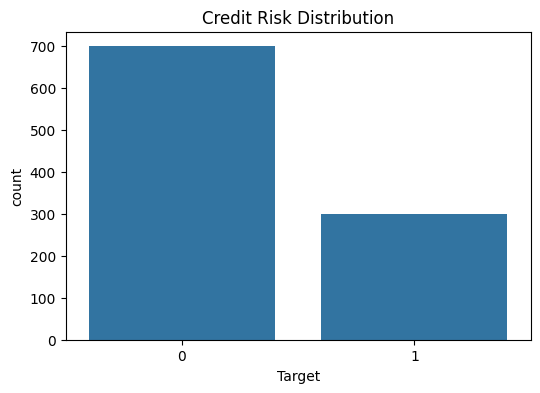

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title('Credit Risk Distribution')
plt.show()

7. Encode Categorical Variables

In [7]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Status', 'CreditHistory', 'Purpose', 'Savings', 'EmploymentDuration',
       'PersonalStatusSex', 'OtherDebtors', 'Property',
       'OtherInstallmentPlans', 'Housing', 'Job', 'Telephone',
       'ForeignWorker'],
      dtype='object')


Label Encoding

In [8]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('✅ Encoding done')

✅ Encoding done


8. Scale Features

In [9]:
X = df.drop('Target', axis=1)
y = df['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Scaling done')

✅ Scaling done


9. Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (800, 20)
Test: (200, 20)


⚖️ 10. Handle Imbalance (SMOTE)

In [11]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('✅ SMOTE applied')
print(pd.Series(y_train_bal).value_counts())

✅ SMOTE applied
Target
1    560
0    560
Name: count, dtype: int64


💾 11. Save Cleaned Data

In [12]:
pd.DataFrame(X_train_bal).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)
pd.Series(y_train_bal).to_csv('y_train.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)

df.to_csv('german_credit_cleaned.csv', index=False)

print('✅ All files saved successfully!')

✅ All files saved successfully!


🧠 ÉTAPE 1 — Entraîner plusieurs modèles

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    acc = model.score(X_test, y_test)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7150
Random Forest: 0.7650
SVM: 0.7600
KNN: 0.6800


📊 ÉTAPE 2 — Comparaison des modèles

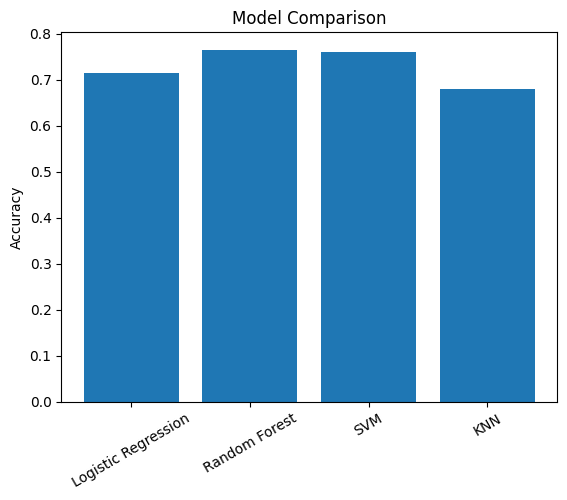

In [14]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

🎯 ÉTAPE 3 — Matrice de confusion

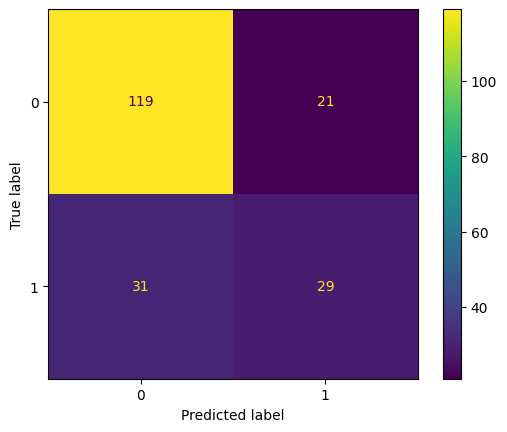

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = RandomForestClassifier()
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

📈 ÉTAPE 4 — ROC Curve

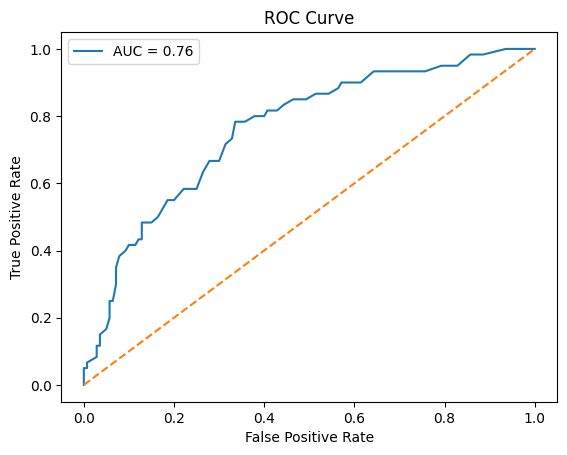

In [16]:
from sklearn.metrics import roc_curve, auc

y_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

⚙️ ÉTAPE 5 — Hyperparameter Tuning (IMPORTANT 🔥)

In [17]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train_bal, y_train_bal)

print("Best params:", grid.best_params_)

Best params: {'max_depth': 10, 'n_estimators': 50}


💾 ÉTAPE 6 — Sauvegarder le modèle

In [18]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']

ÉTAPE 7 — (Option avancée MLOps 🔥)

In [19]:

!pip install mlflow

In [20]:
import mlflow
print("MLflow installé ✅")

MLflow installé ✅


In [21]:
import mlflow

mlflow.start_run()

mlflow.log_param("model", "RandomForest")
mlflow.log_metric("accuracy", model.score(X_test, y_test))

mlflow.end_run()

Étape 1 — Installer FastAPI et Uvicorn

In [22]:
!pip install fastapi uvicorn joblib pandas scikit-learn

Étape 2 — Créer un fichier backend main.py

Étape 3 — Définir le schéma des données d’entrée

In [23]:
from pydantic import BaseModel
class CreditData(BaseModel):
    Status: int
    Duration: float
    CreditHistory: int
    Purpose: int
    CreditAmount: float
    Savings: int
    EmploymentDuration: int
    InstallmentRate: float
    PersonalStatusSex: int
    OtherDebtors: int
    ResidenceDuration: int
    Property: int
    Age: float
    OtherInstallmentPlans: int
    Housing: int
    ExistingCredits: int
    Job: int
    PeopleLiable: int
    Telephone: int
    ForeignWorker: int

Étape 4 — Endpoint de prédiction

In [24]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd

app = FastAPI()
@app.post("/predict")
def predict(data: CreditData):
    # Transformer en DataFrame
    input_df = pd.DataFrame([data.dict()])

    # Appliquer scaling si nécessaire
    input_scaled = scaler.transform(input_df)  # si tu as StandardScaler

    # Prédire
    prediction = model.predict(input_scaled)
    proba = model.predict_proba(input_scaled)[:,1][0]  # probabilité du risque

    return {
        "prediction": int(prediction[0]),
        "risk_probability": float(proba)
    }

🧱 Étape 5 — Endpoint test / ping

In [25]:
@app.get("/")
def root():
    return {"message": "German Credit Risk API is running ✅"}

🧱 Étape 6 — Lancer le serveur

In [26]:
!pip install nest_asyncio uvicorn --quiet

🧱 Étape 8 — Exporter scaler & colonnes (optionnel mais recommandé)

In [27]:
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [28]:
# Shape du dataset
print(f"Nombre de lignes    : {df.shape[0]}")
print(f"Nombre de colonnes  : {df.shape[1]}")
print(f"Shape complet       : {df.shape}")

Nombre de lignes    : 1000
Nombre de colonnes  : 21
Shape complet       : (1000, 21)


In [29]:
# Aperçu complet
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.info()

Shape : (1000, 21)
Colonnes : ['Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings', 'EmploymentDuration', 'InstallmentRate', 'PersonalStatusSex', 'OtherDebtors', 'ResidenceDuration', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing', 'ExistingCredits', 'Job', 'PeopleLiable', 'Telephone', 'ForeignWorker', 'Target']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Status                 1000 non-null   int32
 1   Duration               1000 non-null   int64
 2   CreditHistory          1000 non-null   int32
 3   Purpose                1000 non-null   int32
 4   CreditAmount           1000 non-null   int64
 5   Savings                1000 non-null   int32
 6   EmploymentDuration     1000 non-null   int32
 7   InstallmentRate        1000 non-null   int64
 8   PersonalStatusSex      1000 non-null   int32
